# **Libraries**

In [1]:
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import numpy as np
import pandas as pd
import cv2
import datetime
import matplotlib.pyplot as plt
from PIL import Image
import re
import gc
import glob
import random
import seaborn as sns
import tensorflow as tf

from keras.models import Sequential, Model, load_model
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout, Dense, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.applications import (
    EfficientNetV2S,
    ConvNeXtTiny,
)

2026-05-16 17:14:15.257366: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# **One time execution**

In [ ]:
#pip install split-folders

In [ ]:
#import splitfolders

In [ ]:
'''
def split():
    data_dir = os.path.join('/content/drive/MyDrive/binary_data/data')
    print("No of images in each class of data directory")
    for dir, subdir, files in os.walk(data_dir):
        print(dir,':', str(len(files)))
        
    splitfolders.ratio("/content/drive/MyDrive/binary_data/data", 
                       output = "/content/drive/MyDrive/binary_data_folders",
                       seed = 6, 
                       ratio = (0.8, 0.2), 
                       group_prefix = None, 
                       move = False)

if os.path.exists("/content/drive/MyDrive/binary_data_folders"):
    print("Files already present in splitted ratio 0.8, 0.2")
else:
    split()
    print("Files are splitted in the ratio 0.8, 0.2")
'''

In [ ]:
'''
classes_dict = {0: 'no', 1: 'yes'}
def grey():
    for i in classes_dict.values():
        directory = "binary_data\\" + i
        for filename in os.listdir(directory):
            f = os.path.join(directory, filename)
            img = Image.open(f).convert("L")
            img = img.save(f)
grey()
'''

# **Utility function**

In [3]:
PROJECT_ROOT = "/mnt/c/Users/test/OneDrive - Braude College of Engineering/Software Engineering Stuff/Capstone/Bug-bite-classification-using-a-TC-classification-model"

train = f'{PROJECT_ROOT}/Bug-Data/Binary_Bug_Data/train'
val   = f'{PROJECT_ROOT}/Bug-Data/Binary_Bug_Data/val'

In [4]:
def show_few_images(number_of_examples = 2, predict_using_model = None):
    figure1, ax1 = plt.subplots(number_of_examples,len(os.listdir(train)), figsize=(8, 4*number_of_examples))
    ax1 = ax1.reshape(-1)
    axoff_fun = np.vectorize(lambda ax:ax.axis('off'))
    axoff_fun(ax1)
    axs = 0
    for i, folder in enumerate(os.listdir(train)):
        image_ids = os.listdir(os.path.join(train,folder))
        for j in [random.randrange(0, len(image_ids)) for i in range(0,number_of_examples)]:
            display = plt.imread(os.path.join(train,folder,image_ids[j]))
            plt.axis('off')
            ax1[axs].imshow(display)
            title = 'True:'+folder
            if(predict_using_model):
                predicted_classname = inv_map_classes[np.argmax(inception_best_model.predict(np.array([display])))]
                title = title + '\nPredict :' + predicted_classname
            ax1[axs].set_title(title)
            axs=axs+1

In [5]:
def bar_plot(dir):
    x = len(os.listdir(dir + '/bites'))
    y = len(os.listdir(dir + '/no_bites'))
    category = ['bites', 'no_bites']
    count = [x, y]
    plot = plt.bar(category, count)
    plot[0].set_color('orange')
    plt.title('Number of images per class')
    plt.show()

In [6]:
def plot_performance_metrics(model):
    tr_loss = model.history['loss']
    val_loss = model.history['val_loss']

    tr_accuracy = model.history['accuracy']
    val_accuracy = model.history['val_accuracy']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
    plt.subplots_adjust(wspace=0.40)
    
    # Loss Plot
    ax1.plot(tr_loss)
    ax1.plot(val_loss)
    ax1.grid()
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend(['Train Loss', 'Test Loss'], loc='upper left')
    ax1.set_title('Plot of Train and Test Loss against Epochs')

    # Accuracy Plot
    ax2.plot(tr_accuracy)
    ax2.plot(val_accuracy)
    ax2.grid()
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend(['Train Accuracy', 'Test Accuracy'], loc = 'upper left')
    ax2.set_title('Plot of Train and Test Accuracy against Epoch')
  
    plt.show()

In [7]:
def predict_classes(predictions):
    valResult = predictions.copy()
    valResult[valResult <= 0.5] = 0  
    valResult[valResult > 0.5] = 1   
    return valResult

In [8]:
def plot_confusion_matrix(predictions, labels):
    valResult = predict_classes(predictions)    
    conf_matrix_df= pd.DataFrame(confusion_matrix(labels,valResult),
                                 index=["No", "Yes"],
                                 columns=["No", "Yes"])
    plt.figure(figsize=(7,6))
    plt.title("Confusion Matrix")    
    sns.heatmap(conf_matrix_df, annot = True, annot_kws = {"size" : "20"}, fmt = '.4g')    
    plt.xlabel('\nPredicted', fontsize = 12)    
    plt.ylabel('Actual', fontsize=12, rotation='horizontal', labelpad=40)

    # Get TP, FP, TN and FN
    cm = confusion_matrix(labels, valResult) 
    print('='*50)                                
    print('True Positive  (TP) = ', cm[0][0])
    print('False Positive (FP) = ', cm[0][1])
    print('False Negative (FN) = ', cm[1][0])
    print('True Negative  (TN) = ', cm[1][1])
    print('-'*26)
    
    # Get Precision, Recall and F1 Score.
    if (cm[0][0] + cm[0][1])!=0 and (cm[0][0], cm[1][0])!=0:
        precision= round((cm[0][0] / (cm[0][0] + cm[0][1]))*100, 2) 
        recall   = round((cm[0][0] / (cm[0][0] + cm[1][0]))*100, 2) 
        f1_score = round(2*((precision*recall)/(precision+recall)), 2) 
              
        print(f'Precision Score: {precision}%')
        print(f'Recall Score: {recall}%')
        print(f'F1 Score: {f1_score}%')
        print('='*50) 
        print('\n')

In [9]:
def plot_roc_curve(predictions, labels):
    fpr, tpr, thresholds = roc_curve(labels, predictions)
    auc = roc_auc_score(labels, predictions)
    plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=14)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.plot(fpr, tpr, "g", label="AUC Score = %0.2f" % auc)
    plt.plot([0, 1], [0, 1], "r--")
    plt.ylabel("True Positive Rate (TPR)", fontsize=12)
    plt.xlabel("False Positive Rate (FPR)", fontsize=12)
    plt.legend()
    plt.grid()
    plt.show()

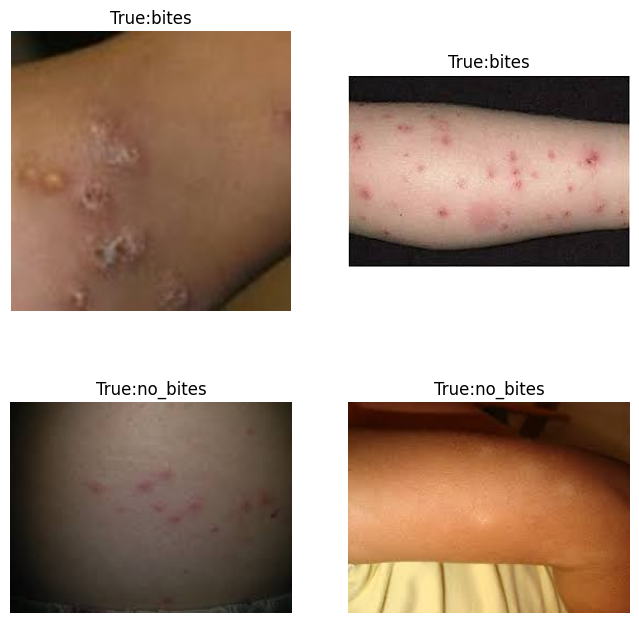

In [10]:
show_few_images(2)

Training images

bites:    267
no_bites: 127
Total:    394
*************************************************


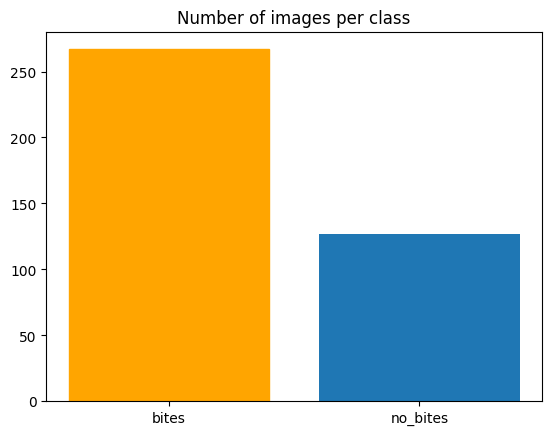


Validation images

bites:    31
no_bites: 31
Total:    62
*************************************************


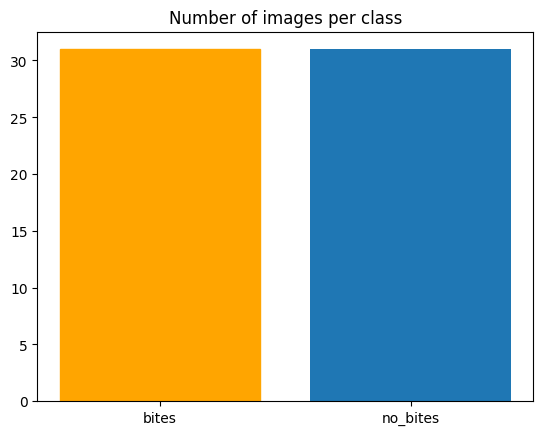

In [11]:
print('Training images\n')
print('bites:   ', len(os.listdir(train + '/bites')))
print('no_bites:', len(os.listdir(train + '/no_bites')))
print('Total:   ', len(os.listdir(train + '/bites')) + len(os.listdir(train + '/no_bites')))
print('*' * 49)
bar_plot(train)
print('\nValidation images\n')
print('bites:   ', len(os.listdir(val + '/bites')))
print('no_bites:', len(os.listdir(val + '/no_bites')))
print('Total:   ', len(os.listdir(val + '/bites')) + len(os.listdir(val + '/no_bites')))
print('*' * 49)
bar_plot(val)

# **Data Preparation**

In [12]:
width, height = 310, 310
train_batch_size = 32
val_batch_size   = 16

Data generator for train set included augmentation and processing (shear, zoom, horizontal_flip, rescale). For the test set only rescale should be made (we don't want to mess with new data - just predict its class).

In [13]:
trainDataGen = ImageDataGenerator(rescale = 1./255, rotation_range = 10, width_shift_range = 0.1)
validationDataGen = ImageDataGenerator(rescale = 1./255.)

It is important to put "shuffle" equal to False in test generator. Otherwise order of test pictures will be distorted by the function and predictions won't fit order expected by Kaggle checking system.

For test data batch size is 1 as we apply trained model to all test pictures without separating them by batches.

In [14]:
train_generator = trainDataGen.flow_from_directory(train, target_size = (height, width), batch_size = train_batch_size, class_mode = 'binary', shuffle = True)
validation_generator = validationDataGen.flow_from_directory(val, target_size = (height, width), batch_size = val_batch_size, class_mode = 'binary', shuffle = False)

Found 393 images belonging to 2 classes.
Found 62 images belonging to 2 classes.


# **EfficientNetV2S**

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
# include_preprocessing=False because our generator already rescales to [0,1]
eff_base = EfficientNetV2S(
    weights='imagenet', include_top=False,
    input_shape=(height, width, 3), pooling='avg',
    include_preprocessing=False
)
for layer in eff_base.layers:
    layer.trainable = False

x = Dense(256, activation='relu')(eff_base.output)
x = Dropout(0.3)(x)
x = Dense(1, activation='sigmoid')(x)
efficientnetv2s_model = Model(eff_base.input, x)

In [ ]:
efficientnetv2s_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
training_steps   = train_generator.samples // train_batch_size
validation_steps = validation_generator.samples // val_batch_size

In [ ]:
eff_save_path = f'{PROJECT_ROOT}/Model_Weights/binary_efficientnetv2s.keras'
eff_callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(eff_save_path, monitor='val_accuracy', save_best_only=True, verbose=0),
]

eff_history = efficientnetv2s_model.fit(
    train_generator,
    steps_per_epoch=training_steps,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=eff_callbacks
)

In [ ]:
efficientnetv2s_model.save(eff_save_path)
print(f'Saved: {eff_save_path}')

In [ ]:
plot_performance_metrics(eff_history)

In [ ]:
validation_generator.reset()
eff_prediction = efficientnetv2s_model.predict(validation_generator, verbose=1)
actual_class = validation_generator.classes

In [ ]:
plot_confusion_matrix(eff_prediction, actual_class)

In [ ]:
plot_roc_curve(eff_prediction, actual_class)
print('=' * 55)
print('\n Classification Report:\n')
print(classification_report(actual_class, predict_classes(eff_prediction), target_names=['bites', 'no_bites']))
print('=' * 55)

# **ConvNeXtTiny**

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
# include_preprocessing=False because our generator already rescales to [0,1]
cnx_base = ConvNeXtTiny(
    weights='imagenet', include_top=False,
    input_shape=(height, width, 3), pooling='avg',
    include_preprocessing=False
)
for layer in cnx_base.layers:
    layer.trainable = False

x = Dense(256, activation='relu')(cnx_base.output)
x = Dropout(0.3)(x)
x = Dense(1, activation='sigmoid')(x)
convnext_tiny_model = Model(cnx_base.input, x)
convnext_tiny_model.summary()

In [ ]:
convnext_tiny_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
training_steps   = train_generator.samples // train_batch_size
validation_steps = validation_generator.samples // val_batch_size

In [ ]:
cnx_save_path = f'{PROJECT_ROOT}/Model_Weights/binary_convnext_tiny.keras'
cnx_callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(cnx_save_path, monitor='val_accuracy', save_best_only=True, verbose=0),
]

cnx_history = convnext_tiny_model.fit(
    train_generator,
    steps_per_epoch=training_steps,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=cnx_callbacks
)

In [ ]:
convnext_tiny_model.save(cnx_save_path)
print(f'Saved: {cnx_save_path}')

In [ ]:
plot_performance_metrics(cnx_history)

In [ ]:
validation_generator.reset()
cnx_prediction = convnext_tiny_model.predict(validation_generator, verbose=1)
actual_class = validation_generator.classes

In [ ]:
plot_confusion_matrix(cnx_prediction, actual_class)

In [ ]:
plot_roc_curve(cnx_prediction, actual_class)
print('=' * 55)
print('\n Classification Report:\n')
print(classification_report(actual_class, predict_classes(cnx_prediction), target_names=['bites', 'no_bites']))
print('=' * 55)